In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

run = pickle.loads(Path(".run.pkl").read_bytes())
card, ev, constants = run["card"], run["evidence"], run["constants"]
gates = {g["number"]: g for g in run["gates"]}
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({"figure.figsize": (9, 3), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10})
INK, GREY, MARK = "#1f4e79", "#a6a6a6", "#c0504d"


def text(value):
    return " ".join(str(value).split()) if value else "—"


def shown(value):
    if value is None:
        return "—"
    if isinstance(value, (list, tuple)):
        return "; ".join(map(str, value)) or "none"
    if isinstance(value, float):
        return float(f"{value:.4g}")
    return value


def table(figures):
    display(pd.Series({k: shown(v) for k, v in figures.items()}, dtype=object).to_frame().T.set_index(pd.Index([""])))


def gate(number):
    g = gates[number]
    reason = g["reason"].removeprefix("not computed: ")
    word = {True: "Passes", False: "Fails", None: "Not computed"}[g["passed"]]
    display(Markdown(f"**{word}**: {reason.rstrip('.')}."))
    if g["figures"]:
        table(g["figures"])


failed = run["failed"]
headline = ("passes gates 1 to 7" if failed is None
            else f"stops at gate {failed}, {gates[failed]['name'].lower()}: {gates[failed]['reason']}")
display(Markdown(f"# {card['id']}\n\nTheory **{card.get('theory', '—')}**. The battery's verdict: "
                 f"the strategy {headline}."))

# TM-047-02-volatility-managed-equities

Theory **TM-047**. The battery's verdict: the strategy stops at gate 3, significance: beats 78.1% of its shifted placebos, fewer than 90%.

## Thesis

In [2]:
prediction = card.get("prediction") or {}
if isinstance(prediction, dict):
    prediction = ", ".join(f"{k}: {v}" for k, v in prediction.items())
display(Markdown(f"**Mechanism.** {text(card.get('mechanism'))}\n\n"
                 f"**Prediction.** {text(prediction)}\n\n"
                 f"**What would refute it.** {text(card.get('refuted_if'))}\n\n"
                 f"**Horizon.** {text(card.get('horizon'))}"))

**Mechanism.** Market volatility is persistent and forecast well from its own recent past, while the equity premium does not rise with it in the short run. A portfolio of equities scaled down when its recent volatility is high, and held in full when it is at or below the long-run volatility of US equities, keeps most of the premium and sheds risk when it is least rewarded, and so earns a higher Sharpe ratio than the same equities held always.

**Prediction.** sign: positive (the alpha of the equities managed by their own volatility over the same equities held always), size: a judgment -- an alpha of about +0.3 to +2% a year, an appraisal ratio of about 0.05 to 0.35, Moreira and Muir's 0.30 for the capped market (1926-2015, as TM-047-01 reported it; the paper is not in the library) and Ang's timed equities (1986-2011) cut for five funds with the cap binding in calm months and for TM-047-01's timing worth 0.02 on the lab's funds; the Sharpe ratio above the five funds held always; the base expected to fail gate 3 or gate 4, likely gate 6 on QQQ's share of the profit (32 to 34% for rules close to the five in equal parts set back monthly, SC-002-01), and gate 2 if its Sharpe ratio falls below 0.4, where the five held always stand

**What would refute it.** Judged before costs, on the market's closes, over the in-sample months from the first target on which the window has 21 returns, the first session of March 2005, to December 2022, the last month ending at the close of 2022-12-30, each month from the close of a target's session to the close of the next target's session: the base's monthly return less the bill's, regressed by ordinary least squares on the monthly return less the bill's of the five funds held in equal parts from the same closes, with standard errors robust to heteroskedasticity, the intercept's t statistic computed apart from the battery. The theory is refuted in this form if the t statistic is -0.35 or below: the equity premium managed by its own volatility no better than held always. Between, short of passing gates 1 to 7, not proven, not refuted; a base that passes gates 1 to 7 while the clause refutes leaves the theory refuted in this form. Of TM-047's refutation criteria the third is graded, in its risk-premium form, the equity premium; its trend form was read by TM-047-01, and the first and second, momentum's, are read in their panic-state form by TM-024-01 and TM-006-01; this card holds no momentum and does not grade them. TM-024-01's equity panic months, published on the momentum tilt's return and with two of the equity markets' monthly returns, stay in the graded sample, disclosed. Reported, not graded: the same regression for the variant; the Sharpe ratios of the base, the variant and the five funds held always, before costs; the share of months with the scale below one, the average scale, and the base's alpha at a beta equal to its average scale; the clause over the months of 2005 to 2013, over those of 2014 to 2022, over the in-sample months without 2008 and 2009, without TM-024-01's equity panic months, and over the holdout, 2023 to 2025; the same regression for SPY alone, managed by its own risk; the base's alpha before and after costs, and the neighbours' and the one-day-late rule's alphas and appraisal ratios.

**Horizon.** months

## Data

In [3]:
x = ev.get("excess")
start, end = constants["in sample"]
cannot_run = gates[1]["reason"].startswith("the strategy cannot run")
broke = gates[1]["reason"].startswith("cannot be computed: ")        # the runs every gate judges broke
evaluated = (f"evaluated from the first session the strategy holds an asset, {x.index[0].date()}, to "
             f"{x.index[-1].date()}" if x is not None and len(x)
             else "not evaluated: the strategy cannot run" if cannot_run
             else f"not evaluated: the runs every gate judges broke ({gates[1]['reason'].split(': ', 1)[1]})"
             if broke else "not evaluated: nothing was held")
display(Markdown(
    f"Daily closes adjusted for dividends and splits, snapshot **{run['snapshot']}**. "
    f"Universe: {', '.join(card['universe'])}. In-sample {start} to {end}, {evaluated}; "
    f"holdout {' to '.join(constants['holdout'])}, opened once, at gate 7. "
    f"Returns are above the Treasury-bill rate, net of costs."))

Daily closes adjusted for dividends and splits, snapshot **2026-09-22+2026-09-23**. Universe: SPY, QQQ, IWM, EFA, EEM. In-sample 2005-01-01 to 2022-12-31, evaluated from the first session the strategy holds an asset, 2005-01-04, to 2022-12-30; holdout 2023-01-01 to 2025-12-31, opened once, at gate 7. Returns are above the Treasury-bill rate, net of costs.

## Signal

The portfolio holds the funds trading on the target's session in equal parts. Its risk is the standard deviation of the equal-weight portfolio's daily returns over the last window sessions to the session before the target, each day's return the average of the returns of the funds that traded it, annualized by the square root of 252. The scale k is min(1, (target / risk) squared) when scaling is "variance" and min(1, target / risk) when it is "volatility", and 1 while the window has fewer than window returns. On the first session of each month, each fund trading holds k/N of the portfolio, N the funds trading, the rest in cash. Everything is read up to the session before; targets are traded at the close.

- **window**: sessions of daily returns whose standard deviation measures the portfolio's risk
- **target**: annual volatility at or below which the portfolio is held in full, Ang's 16% for US equities over 1935-2010
- **scaling**: how the scale follows the risk, a text naming the variant, with no neighbours: "variance", (target / risk) squared, Moreira and Muir's baseline; "volatility", target / risk

,window,target,scaling
base,21,0.16,variance
variant 1,21,0.16,volatility


Parameter neighbours, moved one at a time for gate 6: window at ±25%: 16, 26; window at ±50%: 10, 32; target at ±25%: 0.12, 0.2; target at ±50%: 0.08, 0.24.

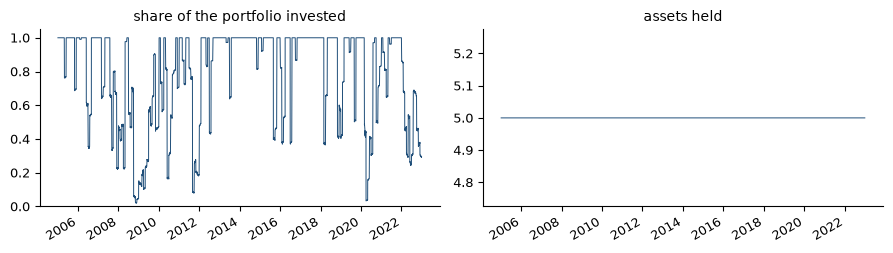

In [4]:
display(Markdown(text(card.get("signal"))))
parameters = card.get("parameters") or {}
if parameters:
    display(Markdown("\n".join(f"- **{k}**: {text(v)}" for k, v in parameters.items())))
variants = pd.DataFrame(card["variants"], index=["base"] + [f"variant {k}" for k in range(1, len(card["variants"]))])
display(variants)
neighbours = card.get("neighbours") or {}
if neighbours:
    display(Markdown("Parameter neighbours, moved one at a time for gate 6: "
                     + "; ".join(f"{p} at ±{step}%: {', '.join(map(str, values))}"
                                 for p, steps in neighbours.items() for step, values in steps.items()) + "."))
if "exposure" in ev:
    fig, (a, b) = plt.subplots(1, 2, figsize=(9, 2.6))
    ev["exposure"].plot(ax=a, color=INK, linewidth=0.7)
    a.set_title("share of the portfolio invested")
    a.set_ylim(0, 1.05)
    ev["assets held"].plot(ax=b, color=INK, linewidth=0.7)
    b.set_title("assets held")
    for axis in (a, b):
        axis.set_xlabel("")
    plt.tight_layout()

## Equity against the benchmark

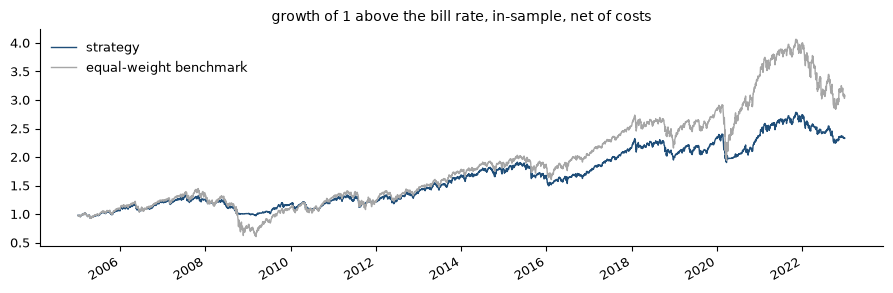

In [5]:
if x is not None and len(x):
    b = ev["benchmark excess"]
    fig, ax = plt.subplots()
    (1 + x).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + b).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title("growth of 1 above the bill rate, in-sample, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
else:
    display(Markdown("The strategy cannot run: there is no equity to draw." if cannot_run
                     else "The runs every gate judges broke: there is no equity to draw." if broke
                     else "Nothing was held in-sample: there is no equity to draw."))

## Gate 1 · Hygiene

Protects against look-ahead, bad data and too little evidence.

**Passes**: no look-ahead on 200 dates, 132 decisions over 18.0 years.

,dates checked,look-ahead breaks,same-day breaks,memory,memory dates checked,memory breaks,data problems,clustered decisions,years in-sample,years needed
,200,0,0,22,100,0,none,132,17.98,5


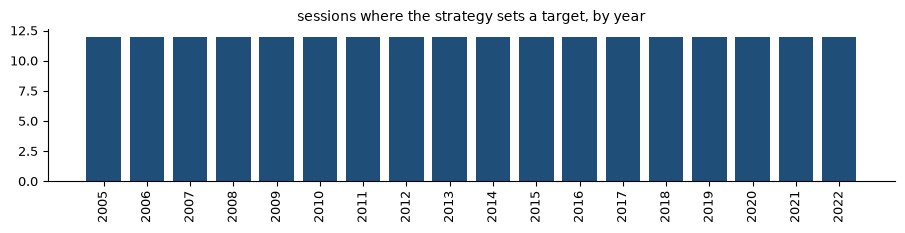

In [6]:
gate(1)
days = ev.get("target days")
if days is not None and len(days):
    per_year = pd.Series(1, index=days).groupby(days.year).sum()
    fig, ax = plt.subplots(figsize=(9, 2.4))
    ax.bar(per_year.index.astype(str), per_year, color=INK)
    breaks = sorted({d.year for variant in ev["timing breaks"].values() for kind in variant.values() for d in kind})
    for year in breaks:
        ax.bar(str(year), per_year.get(year, 0), color=MARK)
    ax.set_title("sessions where the strategy sets a target, by year" + ("; red: a timing break" if breaks else ""))
    ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()

## Gate 2 · Economic edge

Protects against an edge explained by costs or by market exposure.

**Passes**: Sharpe 0.42 against the benchmark's 0.40, alpha 1.25%, 0.41 at twice the costs.

,Sharpe,benchmark Sharpe,alpha,Sharpe at 2x costs,alpha at 2x costs,gross Sharpe,costs a year,costs in Sharpe units
,0.4153,0.3951,0.01255,0.4085,0.01168,0.4221,0.000927,0.006826


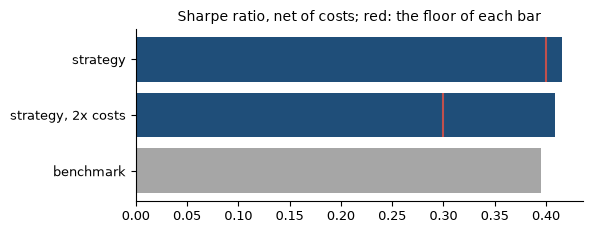

In [7]:
gate(2)
f = gates[2]["figures"]
if f:
    floors = constants["floors"]
    rows = [("benchmark", f["benchmark Sharpe"], GREY, None),
            ("strategy, 2x costs", f["Sharpe at 2x costs"], INK, floors["Sharpe at 2x costs"]),
            ("strategy", f["Sharpe"], INK, floors["Sharpe"])]
    fig, ax = plt.subplots(figsize=(6, 2.4))
    for y, (label, value, colour, floor) in enumerate(rows):
        ax.barh(y, value, color=colour)
        if floor is not None:
            ax.vlines(floor, y - 0.4, y + 0.4, color=MARK, linewidth=1.5)
    ax.set_yticks(range(len(rows)), [r[0] for r in rows])
    ax.set_title("Sharpe ratio, net of costs; red: the floor of each bar")
    plt.tight_layout()

## Gate 3 · Significance

Protects against luck, and against being paid only for being invested. A strategy that holds nearly every asset that trades is close to its benchmark: its placebos differ from it by little, details of the path decide its rank, and gates 2 and 4 judge it.

**Fails**: beats 78.1% of its shifted placebos, fewer than 90%.

,PSR,placebo sessions,placebos,placebos beaten
,0.9786,4531,1000,0.781


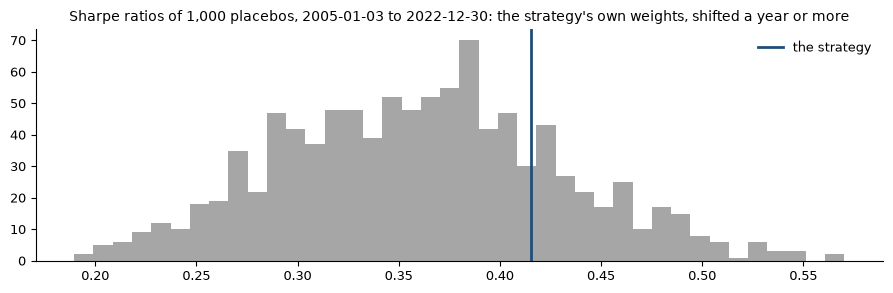

In [8]:
gate(3)
if "placebos" in ev:
    fig, ax = plt.subplots()
    ax.hist(ev["placebos"], bins=40, color=GREY)
    ax.axvline(ev["placebo own Sharpe"], color=INK, linewidth=2, label="the strategy")
    first, last = (d.date() for d in ev["placebo window"])
    ax.set_title(f"Sharpe ratios of {len(ev['placebos']):,} placebos, {first} to {last}: the strategy's own weights, "
                 f"shifted a year or more")
    ax.legend(frameon=False)
    plt.tight_layout()
    if ev.get("placebo late assets"):
        display(Markdown(f"Assets that start trading after {first}: {', '.join(ev['placebo late assets'])}. A placebo "
                         f"shifts their weights only between days when they trade. Where it draws from a day before their "
                         f"start, it keeps their own weights; where it draws from a day after their start onto a day before "
                         f"it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its "
                         f"timing: skill that lies before a late start is judged against placebos that share it, and is "
                         f"found less often. Where the strategy holds none of the assets shifted that day, the shifted "
                         f"weights take that share instead."))

## Gate 4 · Multiple testing

Protects against the best of many tries: the edge, hedged of the benchmark, deflated by every trial the registry holds.

**Fails**: DSR 0.041 below 0.9 over 58 effective trials.

,trials,effective trials,appraisal ratio,Sharpe expected by luck,DSR
,64,58,0.1603,0.6151,0.04114


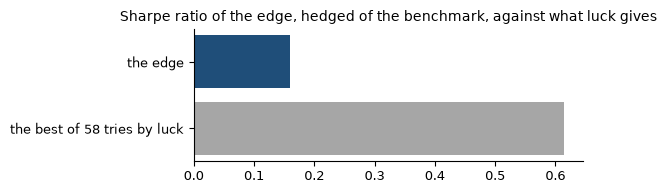

In [9]:
gate(4)
f = gates[4]["figures"]
if f and "appraisal ratio" in f:
    fig, ax = plt.subplots(figsize=(6, 2.0))
    ax.barh([0, 1], [f["Sharpe expected by luck"], f["appraisal ratio"]], color=[GREY, INK])
    tries = f["effective trials"]
    ax.set_yticks([0, 1], [f"the best of {tries} {'try' if tries == 1 else 'tries'} by luck", "the edge"])
    ax.set_title("Sharpe ratio of the edge, hedged of the benchmark, against what luck gives")
    plt.tight_layout()

## Gate 5 · Stability

Protects against an edge that lives in one variant or one episode.

**Fails**: the blend of the variants fails gates 3 and 4; alpha positive in 1 of 5 blocks, fewer than 3.

,blend passes gate 2,blend passes gate 3,blend passes gate 4,worst variant Sharpe,positive blocks,best year,alpha without the best year
,True,False,False,0.4153,1,2017,0.007014


The blend of the variants: gate 3, beats 86.0% of its shifted placebos, fewer than 90%; gate 4, DSR 0.048 below 0.9 over 58 effective trials.

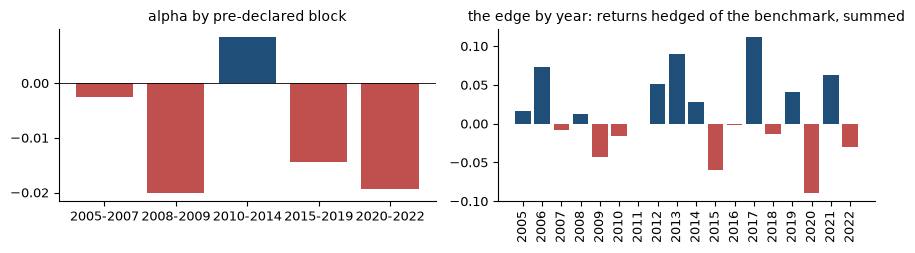

In [10]:
gate(5)
if "blocks" in ev:
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    blocks = pd.Series({k: (v if v is not None else np.nan) for k, v in ev["blocks"].items()})
    a.bar(blocks.index, blocks.fillna(0), color=[INK if v > 0 else MARK for v in blocks.fillna(0)])
    a.set_title("alpha by pre-declared block")
    a.axhline(0, color="black", linewidth=0.6)
    by_year = ev["edge by year"]
    c.bar(by_year.index.astype(str), by_year, color=[INK if v > 0 else MARK for v in by_year])
    c.set_title("the edge by year: returns hedged of the benchmark, summed")
    c.tick_params(axis="x", rotation=90)
    plt.tight_layout()
failed_blend = {n: reason for n, reason in ev.get("blend", {}).items() if gates[5]["figures"].get(f"blend passes gate {n}") is False}
if failed_blend:
    display(Markdown("The blend of the variants: " + "; ".join(f"gate {n}, {r}" for n, r in failed_blend.items()) + "."))

## Gate 6 · Robustness

Protects against a peak, one asset, timing too tight and a clone.

**Fails**: QQQ carries 37% of the P&L, more than 30%.

,neighbour median ratio,lowest ±25% ratio,neighbours that hold the base,worst cluster out,worst cluster out ratio,largest P&L share,asset with the largest share,one day late ratio,highest correlation with a survivor,survivor most correlated
,0.9363,0.9095,none,—,—,0.3693,QQQ,0.9799,—,—


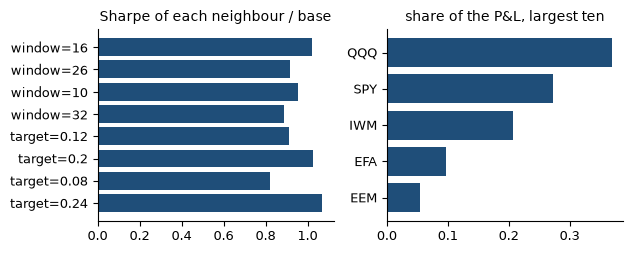

In [11]:
gate(6)
panels = [(k, ev.get(k)) for k in ("neighbours", "clusters out", "P&L shares") if ev.get(k) is not None and len(ev.get(k))]
if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(3.2 * len(panels), 2.6))
    for axis, (name, values) in zip(np.atleast_1d(axes), panels):
        values = pd.Series(values).head(10)
        axis.barh(values.index.astype(str), values, color=INK)
        axis.set_title({"neighbours": "Sharpe of each neighbour / base", "clusters out": "Sharpe without a cluster / base",
                        "P&L shares": "share of the P&L, largest ten"}[name])
        axis.invert_yaxis()
    plt.tight_layout()
if ev.get("without bitcoin"):
    display(Markdown("Without bitcoin, gate 2's figures:"))
    table(ev["without bitcoin"])

## Gate 7 · Sealed holdout

Protects against bugs and large decay, on years kept aside and opened once.

**Passes**: holdout Sharpe 0.91 and alpha -0.88%, both above the in-sample 10th percentile.

,holdout Sharpe,Sharpe floor,holdout alpha,alpha floor,variants rewritten,dates checked,look-ahead breaks,same-day breaks,data problems
,0.9089,-0.2847,-0.008833,-0.0403,0,40,0,0,none


Red: the 10th percentile of the in-sample paths, the floor; blue: the holdout.

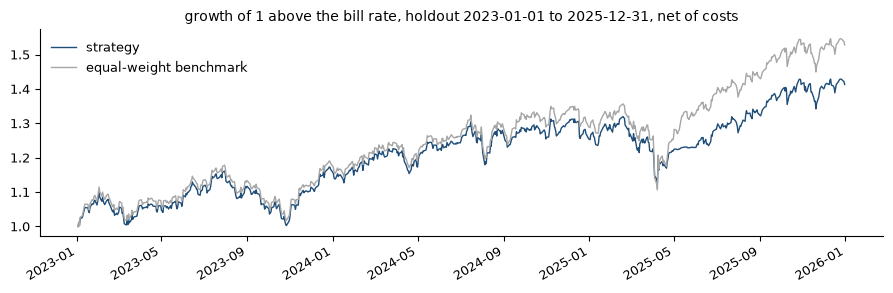

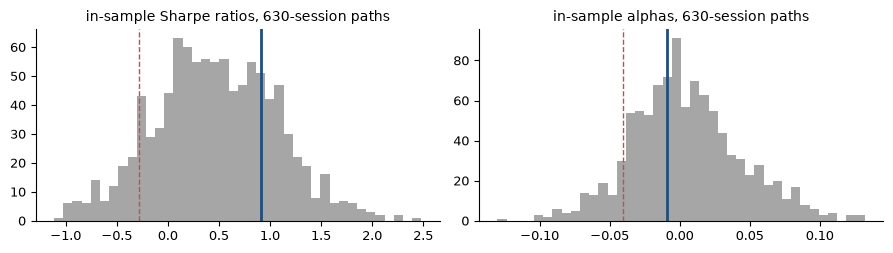

In [12]:
gate(7)
f = gates[7]["figures"]
if "holdout excess" in ev and len(ev["holdout excess"]):
    fig, ax = plt.subplots()
    (1 + ev["holdout excess"]).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + ev["holdout benchmark excess"]).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title(f"growth of 1 above the bill rate, holdout {' to '.join(constants['holdout'])}, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
if "bootstrap" in ev and f:
    pct = constants["percentile"]
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    for axis, key, mark, label in ((a, "Sharpe", "holdout Sharpe", "Sharpe ratio"), (c, "alpha", "holdout alpha", "alpha")):
        axis.hist(ev["bootstrap"][key], bins=40, color=GREY)
        axis.axvline(np.percentile(ev["bootstrap"][key], pct), color=MARK, linestyle="--", linewidth=1)
        axis.axvline(f[mark], color=INK, linewidth=2)
        axis.set_title(f"in-sample {label}s, {constants['window']}-session paths")
    plt.tight_layout()
    display(Markdown(f"Red: the {pct}th percentile of the in-sample paths, the floor; blue: the holdout."))

## Verdict

In [13]:
table = pd.DataFrame([{"gate": f"{g['number']} · {g['name']}",
                       "result": {True: "passes", False: "fails", None: "not computed"}[g["passed"]],
                       "reason": g["reason"].removeprefix("not computed: ")} for g in run["gates"]]).set_index("gate")
display(table)
display(Markdown(f"Thresholds, version {run['thresholds']}. What the verdict means for the theory, and what was "
                 f"learned, is written in [verdict.md](verdict.md)."))

,result,reason
gate,,
1 · Hygiene,passes,"no look-ahead on 200 dates, 132 decisions over 18.0 years"
2 · Economic edge,passes,"Sharpe 0.42 against the benchmark's 0.40, alpha 1.25%, 0.41 at twice the costs"
3 · Significance,fails,"beats 78.1% of its shifted placebos, fewer than 90%"
4 · Multiple testing,fails,DSR 0.041 below 0.9 over 58 effective trials
5 · Stability,fails,"the blend of the variants fails gates 3 and 4; alpha positive in 1 of 5 blocks, fewer than 3"
6 · Robustness,fails,"QQQ carries 37% of the P&L, more than 30%"
7 · Sealed holdout,passes,"holdout Sharpe 0.91 and alpha -0.88%, both above the in-sample 10th percentile"


Thresholds, version 4. What the verdict means for the theory, and what was learned, is written in [verdict.md](verdict.md).